# Potential Outcomes and DAGs

## Overview

Causal inference asks: what would have happened under a different treatment? This question cannot be answered by correlation alone — it requires a causal framework.

**Two dominant frameworks:**

| Framework | Key concept | Tools |
|---|---|---|
| Potential outcomes (Rubin) | Counterfactual: Y(1), Y(0) | ATE, ATT, matching, IPW |
| Structural causal models (Pearl) | DAG encodes assumptions | Backdoor criterion, do-calculus |

**Core quantity — Average Treatment Effect:**
```
ATE = E[Y(1) - Y(0)]
```
The fundamental problem: we observe Y(1) or Y(0) for each unit, never both. Identification requires assumptions about what makes the unobserved counterfactual recoverable from data.

**Key assumptions for observational causal inference:**
1. **SUTVA:** no interference between units, one version of treatment
2. **Ignorability (unconfoundedness):** treatment assignment independent of potential outcomes given observed covariates
3. **Overlap (positivity):** every unit has non-zero probability of receiving either treatment

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

rng = np.random.default_rng(42)
n = 500
# Simulate: stream restoration study
# True causal structure: elevation -> treatment assignment (confound)
#                        elevation -> richness (direct)
#                        treatment -> richness (causal effect = 3.0)
elevation   = rng.uniform(50, 350, n)
elev_scaled = (elevation - elevation.mean()) / elevation.std()
# Treatment probability increases with elevation (confounding)
p_treat = 1 / (1 + np.exp(-0.8*elev_scaled))
treatment = rng.binomial(1, p_treat, n)
# Potential outcomes
Y0 = 20 - 0.04*elevation + rng.normal(0, 3, n)   # untreated richness
Y1 = Y0 + 3.0                                      # treatment adds 3 species (true ATE)
Y_obs = np.where(treatment==1, Y1, Y0)             # observed outcome
df = pd.DataFrame({"elevation":elevation,"treatment":treatment,
                    "richness":Y_obs,"Y0":Y0,"Y1":Y1})
true_ATE = (Y1 - Y0).mean()
naive_diff = df.groupby("treatment")["richness"].mean().diff().iloc[-1]
print(f"True ATE:          {true_ATE:.3f}")
print(f"Naive mean diff:   {naive_diff:.3f}  (biased -- confounded by elevation)")
print(f"Confounding bias:  {naive_diff - true_ATE:.3f}")

True ATE:          3.000
Naive mean diff:   0.940  (biased -- confounded by elevation)
Confounding bias:  -2.060


---
## DAG Visualisation

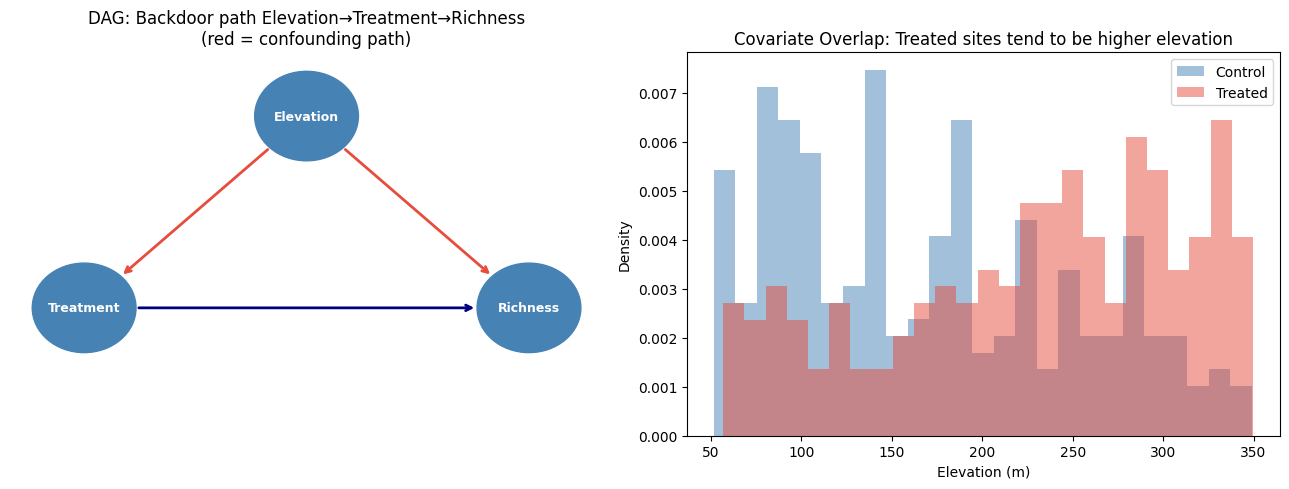

In [2]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
# DAG 1: Confounded observational study
ax = axes[0]
ax.set_xlim(0,4); ax.set_ylim(0,3); ax.axis("off")
nodes = {"Elevation":(2,2.5), "Treatment":(0.5,1), "Richness":(3.5,1)}
for name, (x,y) in nodes.items():
    ax.add_patch(plt.Circle((x,y), 0.35, color="steelblue", zorder=3))
    ax.text(x,y, name, ha="center", va="center", fontsize=9, color="white", fontweight="bold")
edges = [("Elevation","Treatment",True),("Elevation","Richness",True),("Treatment","Richness",False)]
for src, dst, is_backdoor in edges:
    sx,sy = nodes[src]; dx,dy = nodes[dst]
    dx2 = dx-sx; dy2 = dy-sy
    norm = np.sqrt(dx2**2+dy2**2)
    color = "#e74c3c" if is_backdoor else "navy"
    ax.annotate("", xy=(dx-0.35*dx2/norm, dy-0.35*dy2/norm),
                xytext=(sx+0.35*dx2/norm, sy+0.35*dy2/norm),
                arrowprops=dict(arrowstyle="->", color=color, lw=2))
ax.set_title("DAG: Backdoor path Elevation→Treatment→Richness\n(red = confounding path)")
# Overlap plot
ax2 = axes[1]
for t, color, label in [(0,"steelblue","Control"),(1,"#e74c3c","Treated")]:
    mask = df["treatment"]==t
    ax2.hist(df.loc[mask,"elevation"], bins=25, alpha=0.5, color=color,
             density=True, label=label)
ax2.set_xlabel("Elevation (m)"); ax2.set_ylabel("Density")
ax2.set_title("Covariate Overlap: Treated sites tend to be higher elevation")
ax2.legend(); plt.tight_layout(); plt.show()

---
## Ignorability and Overlap

SUTVA assumption checks:
  1. No interference: restoration of one site does not affect neighbours
     -> Check: are sites geographically independent?
  2. One version of treatment: all 'restored' sites restored identically
     -> Check: was the restoration protocol consistent?


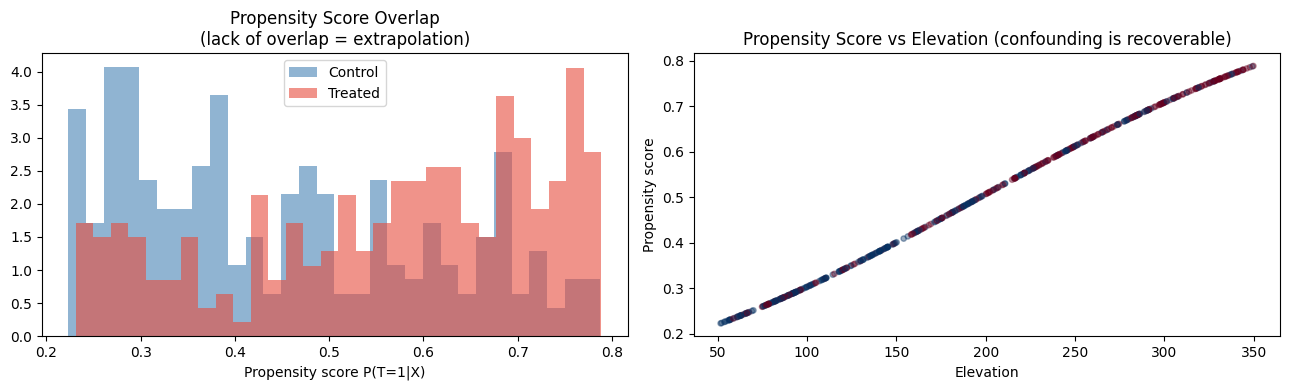

In [3]:
# Check overlap assumption: propensity score distribution
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
X_cov = df[["elevation"]].values
ps_model = LogisticRegression().fit(StandardScaler().fit_transform(X_cov), df["treatment"])
df["ps"] = ps_model.predict_proba(StandardScaler().fit_transform(X_cov))[:,1]
fig, axes = plt.subplots(1,2,figsize=(13,4))
for t, color, label in [(0,"steelblue","Control"),(1,"#e74c3c","Treated")]:
    mask = df["treatment"]==t
    axes[0].hist(df.loc[mask,"ps"], bins=30, alpha=0.6, color=color,
                 density=True, label=label)
axes[0].set_xlabel("Propensity score P(T=1|X)")
axes[0].set_title("Propensity Score Overlap\n(lack of overlap = extrapolation)")
axes[0].legend()
# SUTVA check: no spillover effects assumed
print("SUTVA assumption checks:")
print("  1. No interference: restoration of one site does not affect neighbours")
print("     -> Check: are sites geographically independent?")
print("  2. One version of treatment: all 'restored' sites restored identically")
print("     -> Check: was the restoration protocol consistent?")
axes[1].scatter(df["elevation"], df["ps"], c=df["treatment"],
                cmap="RdBu_r", alpha=0.4, s=15)
axes[1].set_xlabel("Elevation"); axes[1].set_ylabel("Propensity score")
axes[1].set_title("Propensity Score vs Elevation (confounding is recoverable)")
plt.tight_layout(); plt.show()

---
## Backdoor Criterion

In [4]:
# The backdoor criterion: blocking all backdoor paths identifies the causal effect
# Path: Treatment <- Elevation -> Richness
# Backdoor path blocked by conditioning on Elevation
# Adjusted estimate: regress outcome on treatment + confounders
import statsmodels.formula.api as smf
model_unadj = smf.ols("richness ~ treatment", df).fit()
model_adj   = smf.ols("richness ~ treatment + elevation", df).fit()
print("Unadjusted (naive) estimate:")
print(f"  Treatment coef: {model_unadj.params['treatment']:.3f} "
      f"(95% CI [{model_unadj.conf_int().loc['treatment',0]:.3f}, "
      f"{model_unadj.conf_int().loc['treatment',1]:.3f}])")
print(f"\nAdjusted (blocking backdoor via elevation):")
print(f"  Treatment coef: {model_adj.params['treatment']:.3f} "
      f"(95% CI [{model_adj.conf_int().loc['treatment',0]:.3f}, "
      f"{model_adj.conf_int().loc['treatment',1]:.3f}])")
print(f"\nTrue ATE: {true_ATE:.3f}")
print(f"Adjustment recovers the true effect -- elevation was the only confounder")

Unadjusted (naive) estimate:
  Treatment coef: 0.940 (95% CI [0.194, 1.686])

Adjusted (blocking backdoor via elevation):
  Treatment coef: 3.133 (95% CI [2.567, 3.699])

True ATE: 3.000
Adjustment recovers the true effect -- elevation was the only confounder


In [5]:
# Collider bias: conditioning on a collider OPENS a spurious path
# Simulate: Treatment -> Water_clarity <- Richness (collider)
water_clarity = 0.4*Y_obs + 0.3*treatment + rng.normal(0,1,n)
df["water_clarity"] = water_clarity
# Conditioning on water_clarity creates spurious treatment-richness association
model_collider = smf.ols("richness ~ treatment + elevation + water_clarity", df).fit()
print("WARNING: water_clarity is a collider (caused by both outcome and treatment)")
print(f"Model WITHOUT collider: treatment coef = {model_adj.params['treatment']:.3f}")
print(f"Model WITH collider:    treatment coef = {model_collider.params['treatment']:.3f}")
print(f"True ATE: {true_ATE:.3f}")
print("\nConditioning on a collider biases the estimate -- draw the DAG first")

Model WITHOUT collider: treatment coef = 3.133
Model WITH collider:    treatment coef = 1.001
True ATE: 3.000

Conditioning on a collider biases the estimate -- draw the DAG first


---

## Common Pitfalls

**1. Confusing association with causation without a causal model**  
Regression coefficients describe conditional associations, not causal effects, unless the identification assumptions are met. Always draw the causal DAG before interpreting any coefficient as a treatment effect.

**2. Controlling for colliders**  
A collider is a variable caused by both the treatment and the outcome. Controlling for it opens a spurious association between treatment and outcome (collider bias). Identify colliders in the DAG before deciding what to condition on.

**3. Ignoring the overlap assumption**  
If treated and control units have no overlap in covariate space, the counterfactual for some units must be extrapolated rather than estimated. Causal estimates in regions of poor overlap are model-dependent and unreliable. Always plot propensity score distributions for both groups.

**4. Assuming ignorability without justification**  
Ignorability (no unmeasured confounding) is untestable from the data — it is a substantive assumption about the data-generating process. Always ask: is there any unmeasured variable that affects both treatment assignment and the outcome? If yes, the assumption is violated.

**5. Using the naive mean difference as the ATE in an observational study**  
The naive difference in means conflates the treatment effect with confounding. It equals the ATE only in a randomised experiment. In observational data, always adjust for confounders identified by the DAG.

---
*python_methods_library - Samantha McGarrigle*